In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache = pickle.load(f)

In [5]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

SSR_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.8, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
train_ds = filter_by_elev(SSR_synth_ds, {14, 15, 16})
valid_ds = filter_by_elev(meas_ds, {14, 15, 16})
test_ds = filter_by_elev(meas_ds, {17})

In [7]:
class NormalisedCircularQuadraticLoss(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes
        self.register_buffer("distance_matrix", self._compute_circular_distance_matrix())

    def _compute_circular_distance_matrix(self):
        K = self.num_classes
        i_indices = torch.arange(K).view(K, 1)
        j_indices = torch.arange(K).view(1, K)
        abs_diff = torch.abs(i_indices - j_indices)
        circular_dist = torch.minimum(abs_diff, K - abs_diff).float()
        max_dist = K // 2  # furthest possible circular distance
        normalized = (circular_dist / max_dist) ** 2  # now bounded in [0, 1]
        return normalized

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        target_distances = self.distance_matrix[targets]
        loss = torch.sum(probs * target_distances, dim=1)
        return loss.mean()

In [8]:
class MultiTaskDataset(Dataset):
    def __init__(self, dataset, sample_to_azimuth_idx, vehicle_classes, azimuth_classes):
        self.dataset = dataset
        self.sample_to_azimuth_idx = sample_to_azimuth_idx
        self.vehicle_classes = vehicle_classes
        self.azimuth_classes = azimuth_classes
        # keep only samples that have a valid azimuth label
        self.valid_indices = [i for i in range(len(dataset)) if i in sample_to_azimuth_idx]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        original_idx = self.valid_indices[idx]
        image, vehicle_label = self.dataset[original_idx]
        azimuth_label = self.sample_to_azimuth_idx[original_idx]
        return image, vehicle_label, azimuth_label

    @property
    def samples(self):
        return [
            (self.dataset.samples[i][0], self.dataset.samples[i][1], self.sample_to_azimuth_idx[i])
            for i in self.valid_indices
        ]

In [9]:
def build_global_bin_to_label(*datasets, bin_width=10):
    """Step 1: scan all provided datasets, return a fixed bin_to_label map + azimuth_classes."""
    seen_bins = set()
    for ds in datasets:
        for path, _ in ds.samples:
            az = parse_metadata(path)['azim']
            if az is not None:
                raw_bin = (az // bin_width) * bin_width
                seen_bins.add(raw_bin)

    sorted_bins = sorted(seen_bins)
    bin_to_label = {b: i for i, b in enumerate(sorted_bins)}
    azimuth_classes = [f"az{b}" for b in sorted_bins]
    return bin_to_label, azimuth_classes


def assign_azimuth_labels(dataset, bin_to_label, bin_width=10):
    """Step 2: apply a fixed bin_to_label map to one split's own samples/indices."""
    sample_to_azimuth_idx = {}
    for idx, (path, _) in enumerate(dataset.samples):
        az = parse_metadata(path)['azim']
        if az is None:
            continue
        raw_bin = (az // bin_width) * bin_width
        sample_to_azimuth_idx[idx] = bin_to_label[raw_bin]
    return sample_to_azimuth_idx

In [10]:
bin_to_label, azimuth_classes = build_global_bin_to_label(train_ds, valid_ds, test_ds, bin_width=10)

train_azimuth_map = assign_azimuth_labels(train_ds, bin_to_label)
valid_azimuth_map = assign_azimuth_labels(valid_ds, bin_to_label)
test_azimuth_map  = assign_azimuth_labels(test_ds, bin_to_label)

multitask_train_ds = MultiTaskDataset(train_ds, train_azimuth_map, train_ds.classes, azimuth_classes)
multitask_valid_ds = MultiTaskDataset(valid_ds, valid_azimuth_map, valid_ds.classes, azimuth_classes)
multitask_test_ds  = MultiTaskDataset(test_ds,  test_azimuth_map,  test_ds.classes,  azimuth_classes)

In [11]:
assert no_aug_synth_ds.classes == meas_ds.classes, "Vehicle class lists differ between synth and measured!"

In [12]:
print(len(valid_ds), len(valid_azimuth_map))  # should be close, not wildly different
print(len(test_ds), len(test_azimuth_map))

806 806
539 539


In [13]:
class MultiTaskResNet18(nn.Module):
    def __init__(self, num_vehicle_classes, num_azimuth_classes, dropout_p=0.4):
        super().__init__()
        backbone = models.resnet18(weights=None)
        self.trunk = nn.Sequential(*list(backbone.children())[:-1])  # everything except fc
        in_features = backbone.fc.in_features

        self.dropout = nn.Dropout(p=dropout_p)
        self.fc_vehicle = nn.Linear(in_features, num_vehicle_classes)
        self.fc_azimuth = nn.Linear(in_features, num_azimuth_classes)

    def forward(self, x):
        feats = self.trunk(x).flatten(1)
        feats = self.dropout(feats)
        return self.fc_vehicle(feats), self.fc_azimuth(feats)

In [14]:
dataset_sizes = {
    "train": len(multitask_train_ds),
    "val": len(multitask_valid_ds),
    "test": len(multitask_test_ds)
}

num_vehicle_classes = len(multitask_train_ds.vehicle_classes)
num_azimuth_classes = len(multitask_train_ds.azimuth_classes)

# Normalised Circular Loss

In [15]:
# seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
seed_lst = [10]
vehicle_weight, azimuth_weight = 1.0, 1.0  # tune if one task dominates
circ_weight = 1.0

train_loss, val_loss = [], []
train_vehicle_acc, val_vehicle_acc = [], []
train_azimuth_acc, val_azimuth_acc = [], []

for i, seed in enumerate(seed_lst):
    start = time.perf_counter()
    
    print(f"Training Run {i}: seed {seed}")
    set_seed(seed)
    
    dataloaders = {
        "train": DataLoader(multitask_train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(multitask_valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(multitask_test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }

    model = MultiTaskResNet18(
        num_vehicle_classes=len(multitask_train_ds.vehicle_classes),
        num_azimuth_classes=len(multitask_train_ds.azimuth_classes)
    )

    criterion = nn.CrossEntropyLoss()
    circular_criterion = NormalisedCircularQuadraticLoss(num_azimuth_classes)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=2e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=200, eta_min=3e-7)

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    circular_criterion = circular_criterion.to(device)
    
    history = {
        "train_loss": [], "val_loss": [],
        "train_vehicle_acc": [], "val_vehicle_acc": [],
        "train_azimuth_acc": [], "val_azimuth_acc": []
    }

    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.trunk[0].weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_vehicle_corrects = 0
            running_azimuth_corrects = 0
            
            running_azimuth_ce = 0.0      # NEW
            running_azimuth_circ = 0.0    # NEW
            
            for inputs, vehicle_labels, azimuth_labels in dataloaders[phase]:
                inputs = inputs.to(device)
                vehicle_labels = vehicle_labels.to(device)
                azimuth_labels = azimuth_labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    vehicle_logits, azimuth_logits = model(inputs)
                    _, vehicle_preds = torch.max(vehicle_logits, 1)
                    _, azimuth_preds = torch.max(azimuth_logits, 1)

                    loss_vehicle = criterion(vehicle_logits, vehicle_labels)
                    
                    loss_azimuth_ce = criterion(azimuth_logits, azimuth_labels)
                    loss_azimuth_circ = circular_criterion(azimuth_logits, azimuth_labels)
                    loss_azimuth =  loss_azimuth_ce + circ_weight * loss_azimuth_circ
                    
                    loss = vehicle_weight * loss_vehicle + azimuth_weight * loss_azimuth
                    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_vehicle_corrects += (vehicle_preds == vehicle_labels).sum().item()
                running_azimuth_corrects += (azimuth_preds == azimuth_labels).sum().item()
                running_azimuth_ce += loss_azimuth_ce.item() * inputs.size(0)      # NEW
                running_azimuth_circ += loss_azimuth_circ.item() * inputs.size(0) # NEW

                
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_vehicle_acc = running_vehicle_corrects / dataset_sizes[phase]
            epoch_azimuth_acc = running_azimuth_corrects / dataset_sizes[phase]
            epoch_azimuth_ce = running_azimuth_ce / dataset_sizes[phase]      # NEW
            epoch_azimuth_circ = running_azimuth_circ / dataset_sizes[phase] # NEW

            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_vehicle_acc"].append(epoch_vehicle_acc)
            history[f"{phase}_azimuth_acc"].append(epoch_azimuth_acc)

            print(f"{phase} Loss: {epoch_loss:.10f} Vehicle Acc: {epoch_vehicle_acc:.10f} Azimuth Acc: {epoch_azimuth_acc:.10f}")
            if phase == "train":
                print(f"CE: {epoch_azimuth_ce:.10f}  weighted Circ: {circ_weight * epoch_azimuth_circ:.10f}")
            
            
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")

    print("Training complete!")

    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_vehicle_acc.append(history["train_vehicle_acc"])
    val_vehicle_acc.append(history["val_vehicle_acc"])
    train_azimuth_acc.append(history["train_azimuth_acc"])
    val_azimuth_acc.append(history["val_azimuth_acc"])

    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/multitask/SSR_w_noise_ncql/rn18_seed{seed}_b16_circ.pth"))
    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")

train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_vehicle_acc = np.array(train_vehicle_acc)
val_vehicle_acc = np.array(val_vehicle_acc)
train_azimuth_acc = np.array(train_azimuth_acc)
val_azimuth_acc = np.array(val_azimuth_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000224
train Loss: 4.0120366134 Vehicle Acc: 0.2965260546 Azimuth Acc: 0.3101736973
CE: 1.6965523441  weighted Circ: 0.3236236859
val Loss: 6.3219969539 Vehicle Acc: 0.1178660050 Azimuth Acc: 0.1910669975
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 2.4403963456 Vehicle Acc: 0.5558312655 Azimuth Acc: 0.5831265509
CE: 1.0209616442  weighted Circ: 0.1425905044
val Loss: 2.1116076805 Vehicle Acc: 0.6625310174 Azimuth Acc: 0.6476426799
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 1.4206755070 Vehicle Acc: 0.7940446650 Azimuth Acc: 0.7456575682
CE: 0.6639748069  weighted Circ: 0.0801262888
val Loss: 2.0913398813 Vehicle Acc: 0.6550868486 Azimuth Acc: 0.6042183623
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 1.0810074185 Vehicle Acc: 0.8709677419 Azimuth Acc: 0.7729528536
CE: 0.5710533177  weighted Circ: 0.0646528536
val Loss: 1.5854946795 Vehicle Acc: 0.7369727047 Azimuth Acc: 0.7146401985
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.871

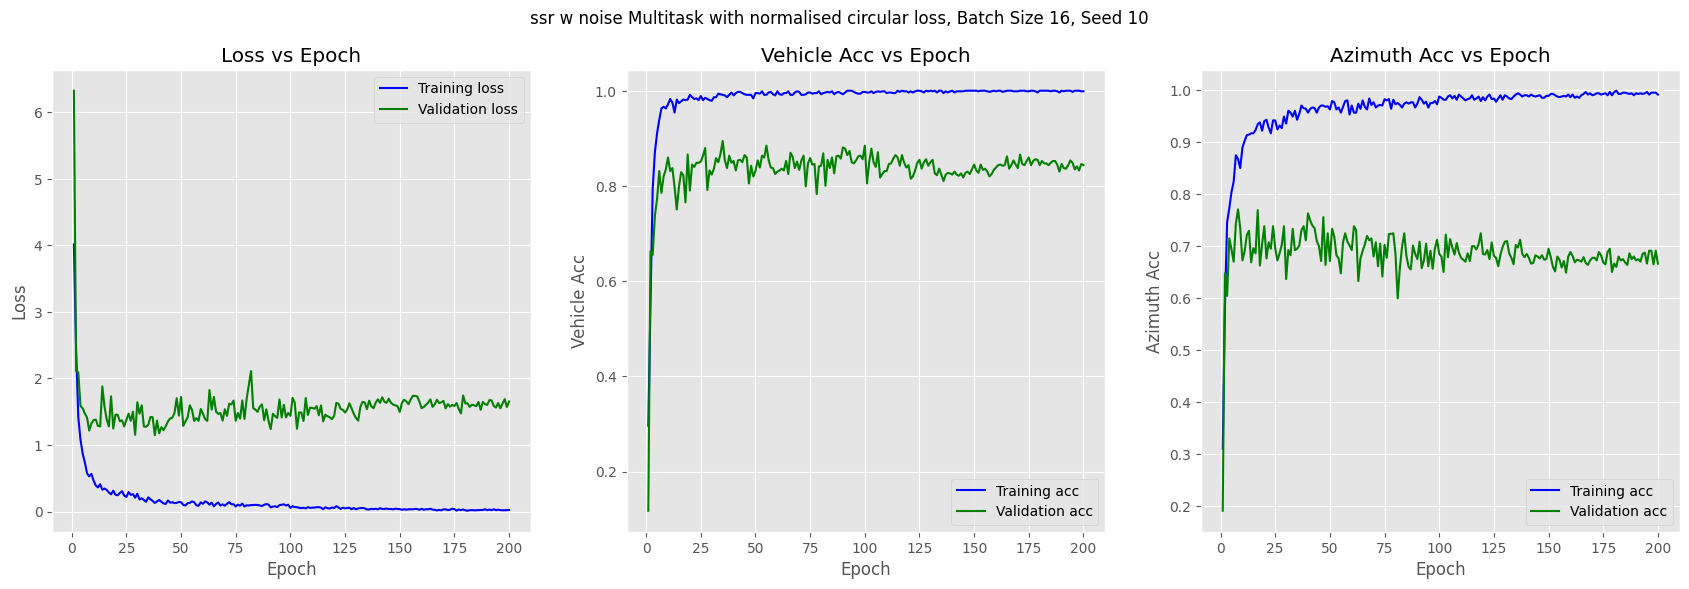

In [16]:
row, col = train_loss.shape

for i, seed in enumerate(seed_lst):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (21, 6))
    
        ax0 = fig.add_subplot(1, 3, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 3, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_vehicle_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_vehicle_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Vehicle Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Vehicle Acc")
        ax1.legend()
        ax1.grid(True)

        ax2 = fig.add_subplot(1, 3, 3)
        ax2.plot(np.arange(1, num_epochs+1), train_azimuth_acc[i, :], label = "Training acc", c = "blue")
        ax2.plot(np.arange(1, num_epochs+1), val_azimuth_acc[i, :], label = "Validation acc", c = "green")
        ax2.set_title("Azimuth Acc vs Epoch")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Azimuth Acc")
        ax2.legend()
        ax2.grid(True)
        
        fig.suptitle(f"ssr w noise Multitask with normalised circular loss, Batch Size 16, Seed {seed}")
        plt.show()

In [15]:
test_dataloader = DataLoader(multitask_test_ds, batch_size=32, shuffle=False, 
                            num_workers=8, pin_memory=True, persistent_workers=True, 
                            prefetch_factor=4)

seed_lst = [10]
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i} with seed {seed}")
    
    model = MultiTaskResNet18(
        num_vehicle_classes=len(multitask_train_ds.vehicle_classes),
        num_azimuth_classes=len(multitask_train_ds.azimuth_classes)
    )
    # Load your trained weights
    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/multitask/SSR_w_noise_ncql/rn18_seed{seed}_b16_circ.pth"),
        map_location=device
    ))
    
    model = model.to(device)
    model.eval()

    n_test = dataset_sizes["test"]
    vehicle_labels_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    vehicle_preds_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    azimuth_labels_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    azimuth_preds_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    
    idx = 0
    with torch.no_grad():
        for inputs, vehicle_labels, azimuth_labels in test_dataloader:
            inputs = inputs.to(device)
            vehicle_labels = vehicle_labels.to(device)
            azimuth_labels = azimuth_labels.to(device)
    
            vehicle_logits, azimuth_logits = model(inputs)
            _, vehicle_preds = torch.max(vehicle_logits, 1)
            _, azimuth_preds = torch.max(azimuth_logits, 1)
    
            batch_size = vehicle_labels.size(0)
            vehicle_labels_tensor[idx : idx + batch_size] = vehicle_labels
            vehicle_preds_tensor[idx : idx + batch_size] = vehicle_preds
            azimuth_labels_tensor[idx : idx + batch_size] = azimuth_labels
            azimuth_preds_tensor[idx : idx + batch_size] = azimuth_preds
            idx += batch_size

    torch.cuda.synchronize()
    
    test_veh_acc = (vehicle_labels_tensor == vehicle_preds_tensor).float().mean()
    test_azimuth_acc = (azimuth_labels_tensor == azimuth_preds_tensor).float().mean()
    test_acc = ((vehicle_labels_tensor == vehicle_preds_tensor) & (azimuth_labels_tensor == azimuth_preds_tensor)).float().mean()
    print(f"Test Vehicle Accuracy: {test_veh_acc *100:.4f}\nTest Azimuth Accuracy: {test_azimuth_acc * 100:.4f}\nTest Joint Accuracy: {test_acc * 100:.4f}\n")
    test_acc_lst.append(test_acc.item())

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0 with seed 10
Test Vehicle Accuracy: 89.6104
Test Azimuth Accuracy: 70.5009
Test Joint Accuracy: 63.2653

Min: 63.2653
Max: 63.2653
Avg, Std: 63.2653, 0.0000


# $5 \times $ Normalised Circular Loss

In [17]:
# seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
seed_lst = [10]
vehicle_weight, azimuth_weight = 1.0, 1.0  # tune if one task dominates
circ_weight = 5.0

train_loss, val_loss = [], []
train_vehicle_acc, val_vehicle_acc = [], []
train_azimuth_acc, val_azimuth_acc = [], []

for i, seed in enumerate(seed_lst):
    start = time.perf_counter()
    
    print(f"Training Run {i}: seed {seed}")
    set_seed(seed)
    
    dataloaders = {
        "train": DataLoader(multitask_train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(multitask_valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(multitask_test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }

    model = MultiTaskResNet18(
        num_vehicle_classes=len(multitask_train_ds.vehicle_classes),
        num_azimuth_classes=len(multitask_train_ds.azimuth_classes)
    )

    criterion = nn.CrossEntropyLoss()
    circular_criterion = NormalisedCircularQuadraticLoss(num_azimuth_classes)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=2e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=200, eta_min=3e-7)

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    circular_criterion = circular_criterion.to(device)
    
    history = {
        "train_loss": [], "val_loss": [],
        "train_vehicle_acc": [], "val_vehicle_acc": [],
        "train_azimuth_acc": [], "val_azimuth_acc": []
    }

    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.trunk[0].weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_vehicle_corrects = 0
            running_azimuth_corrects = 0
            
            running_azimuth_ce = 0.0      # NEW
            running_azimuth_circ = 0.0    # NEW
            
            for inputs, vehicle_labels, azimuth_labels in dataloaders[phase]:
                inputs = inputs.to(device)
                vehicle_labels = vehicle_labels.to(device)
                azimuth_labels = azimuth_labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    vehicle_logits, azimuth_logits = model(inputs)
                    _, vehicle_preds = torch.max(vehicle_logits, 1)
                    _, azimuth_preds = torch.max(azimuth_logits, 1)

                    loss_vehicle = criterion(vehicle_logits, vehicle_labels)
                    
                    loss_azimuth_ce = criterion(azimuth_logits, azimuth_labels)
                    loss_azimuth_circ = circular_criterion(azimuth_logits, azimuth_labels)
                    loss_azimuth =  loss_azimuth_ce + circ_weight * loss_azimuth_circ
                    
                    loss = vehicle_weight * loss_vehicle + azimuth_weight * loss_azimuth
                    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_vehicle_corrects += (vehicle_preds == vehicle_labels).sum().item()
                running_azimuth_corrects += (azimuth_preds == azimuth_labels).sum().item()
                running_azimuth_ce += loss_azimuth_ce.item() * inputs.size(0)      # NEW
                running_azimuth_circ += loss_azimuth_circ.item() * inputs.size(0) # NEW

                
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_vehicle_acc = running_vehicle_corrects / dataset_sizes[phase]
            epoch_azimuth_acc = running_azimuth_corrects / dataset_sizes[phase]
            epoch_azimuth_ce = running_azimuth_ce / dataset_sizes[phase]      # NEW
            epoch_azimuth_circ = running_azimuth_circ / dataset_sizes[phase] # NEW

            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_vehicle_acc"].append(epoch_vehicle_acc)
            history[f"{phase}_azimuth_acc"].append(epoch_azimuth_acc)

            print(f"{phase} Loss: {epoch_loss:.10f} Vehicle Acc: {epoch_vehicle_acc:.10f} Azimuth Acc: {epoch_azimuth_acc:.10f}")
            if phase == "train":
                print(f"CE: {epoch_azimuth_ce:.10f}  weighted Circ: {circ_weight * epoch_azimuth_circ:.10f}")
            
            
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")

    print("Training complete!")

    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_vehicle_acc.append(history["train_vehicle_acc"])
    val_vehicle_acc.append(history["val_vehicle_acc"])
    train_azimuth_acc.append(history["train_azimuth_acc"])
    val_azimuth_acc.append(history["val_azimuth_acc"])

    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/multitask/SSR_w_noise_ncql/rn18_seed{seed}_b16_circ5.pth"))
    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")

train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_vehicle_acc = np.array(train_vehicle_acc)
val_vehicle_acc = np.array(val_vehicle_acc)
train_azimuth_acc = np.array(train_azimuth_acc)
val_azimuth_acc = np.array(val_azimuth_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000224
train Loss: 5.1497061093 Vehicle Acc: 0.2369727047 Azimuth Acc: 0.3176178660
CE: 1.6645579752  weighted Circ: 1.4139844422
val Loss: 5.5189543054 Vehicle Acc: 0.1712158809 Azimuth Acc: 0.2617866005
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 3.0058627614 Vehicle Acc: 0.4652605459 Azimuth Acc: 0.6066997519
CE: 0.9406041104  weighted Circ: 0.5397276463
val Loss: 2.8683886416 Vehicle Acc: 0.4689826303 Azimuth Acc: 0.6451612903
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 1.9115673993 Vehicle Acc: 0.6439205955 Azimuth Acc: 0.7332506203
CE: 0.6101531573  weighted Circ: 0.2984699599
val Loss: 2.6758717461 Vehicle Acc: 0.6501240695 Azimuth Acc: 0.6066997519
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 1.4688346912 Vehicle Acc: 0.7828784119 Azimuth Acc: 0.7803970223
CE: 0.5495024940  weighted Circ: 0.2492356334
val Loss: 1.9760445277 Vehicle Acc: 0.7233250620 Azimuth Acc: 0.6774193548
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 1.142

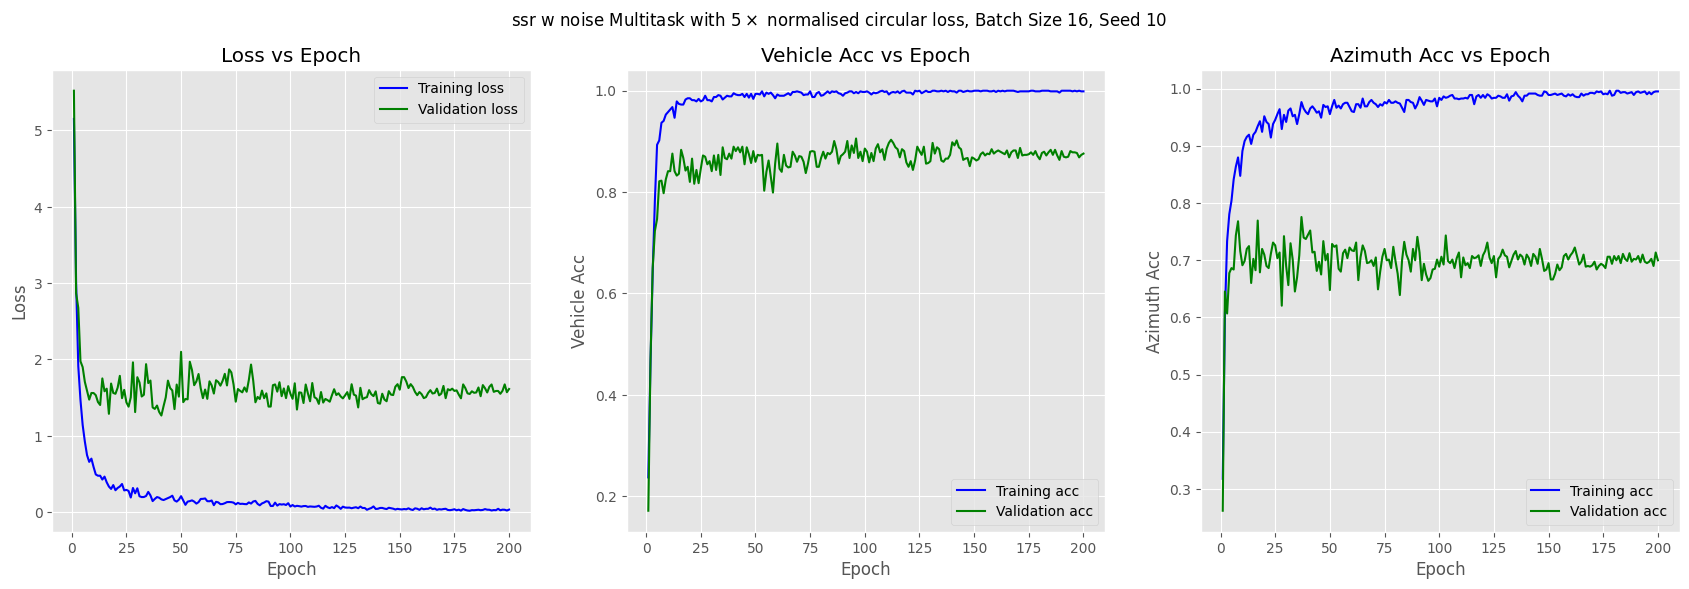

In [18]:
row, col = train_loss.shape

for i, seed in enumerate(seed_lst):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (21, 6))
    
        ax0 = fig.add_subplot(1, 3, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 3, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_vehicle_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_vehicle_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Vehicle Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Vehicle Acc")
        ax1.legend()
        ax1.grid(True)

        ax2 = fig.add_subplot(1, 3, 3)
        ax2.plot(np.arange(1, num_epochs+1), train_azimuth_acc[i, :], label = "Training acc", c = "blue")
        ax2.plot(np.arange(1, num_epochs+1), val_azimuth_acc[i, :], label = "Validation acc", c = "green")
        ax2.set_title("Azimuth Acc vs Epoch")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Azimuth Acc")
        ax2.legend()
        ax2.grid(True)
        
        fig.suptitle(rf"ssr w noise Multitask with $5 \times $ normalised circular loss, Batch Size 16, Seed {seed}")
        plt.show()

In [16]:
test_dataloader = DataLoader(multitask_test_ds, batch_size=32, shuffle=False, 
                            num_workers=8, pin_memory=True, persistent_workers=True, 
                            prefetch_factor=4)

seed_lst = [10]
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i} with seed {seed}")
    
    model = MultiTaskResNet18(
        num_vehicle_classes=len(multitask_train_ds.vehicle_classes),
        num_azimuth_classes=len(multitask_train_ds.azimuth_classes)
    )
    # Load your trained weights
    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/multitask/SSR_w_noise_ncql/rn18_seed{seed}_b16_circ5.pth"),
        map_location=device
    ))
    
    model = model.to(device)
    model.eval()

    n_test = dataset_sizes["test"]
    vehicle_labels_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    vehicle_preds_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    azimuth_labels_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    azimuth_preds_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    
    idx = 0
    with torch.no_grad():
        for inputs, vehicle_labels, azimuth_labels in test_dataloader:
            inputs = inputs.to(device)
            vehicle_labels = vehicle_labels.to(device)
            azimuth_labels = azimuth_labels.to(device)
    
            vehicle_logits, azimuth_logits = model(inputs)
            _, vehicle_preds = torch.max(vehicle_logits, 1)
            _, azimuth_preds = torch.max(azimuth_logits, 1)
    
            batch_size = vehicle_labels.size(0)
            vehicle_labels_tensor[idx : idx + batch_size] = vehicle_labels
            vehicle_preds_tensor[idx : idx + batch_size] = vehicle_preds
            azimuth_labels_tensor[idx : idx + batch_size] = azimuth_labels
            azimuth_preds_tensor[idx : idx + batch_size] = azimuth_preds
            idx += batch_size

    torch.cuda.synchronize()
    
    test_veh_acc = (vehicle_labels_tensor == vehicle_preds_tensor).float().mean()
    test_azimuth_acc = (azimuth_labels_tensor == azimuth_preds_tensor).float().mean()
    test_acc = ((vehicle_labels_tensor == vehicle_preds_tensor) & (azimuth_labels_tensor == azimuth_preds_tensor)).float().mean()
    print(f"Test Vehicle Accuracy: {test_veh_acc *100:.4f}\nTest Azimuth Accuracy: {test_azimuth_acc * 100:.4f}\nTest Joint Accuracy: {test_acc * 100:.4f}\n")
    test_acc_lst.append(test_acc.item())

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0 with seed 10
Test Vehicle Accuracy: 90.9091
Test Azimuth Accuracy: 71.7996
Test Joint Accuracy: 66.0482

Min: 66.0482
Max: 66.0482
Avg, Std: 66.0482, 0.0000


# Normalised Circular Loss with SSR = 0.8

In [15]:
# seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
seed_lst = [10]
vehicle_weight, azimuth_weight = 1.0, 1.0  # tune if one task dominates
circ_weight = 1.0

train_loss, val_loss = [], []
train_vehicle_acc, val_vehicle_acc = [], []
train_azimuth_acc, val_azimuth_acc = [], []

for i, seed in enumerate(seed_lst):
    start = time.perf_counter()
    
    print(f"Training Run {i}: seed {seed}")
    set_seed(seed)
    
    dataloaders = {
        "train": DataLoader(multitask_train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(multitask_valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(multitask_test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }

    model = MultiTaskResNet18(
        num_vehicle_classes=len(multitask_train_ds.vehicle_classes),
        num_azimuth_classes=len(multitask_train_ds.azimuth_classes)
    )

    criterion = nn.CrossEntropyLoss()
    circular_criterion = NormalisedCircularQuadraticLoss(num_azimuth_classes)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=2e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=200, eta_min=3e-7)

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    circular_criterion = circular_criterion.to(device)
    
    history = {
        "train_loss": [], "val_loss": [],
        "train_vehicle_acc": [], "val_vehicle_acc": [],
        "train_azimuth_acc": [], "val_azimuth_acc": []
    }

    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.trunk[0].weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_vehicle_corrects = 0
            running_azimuth_corrects = 0
            
            running_azimuth_ce = 0.0      # NEW
            running_azimuth_circ = 0.0    # NEW
            
            for inputs, vehicle_labels, azimuth_labels in dataloaders[phase]:
                inputs = inputs.to(device)
                vehicle_labels = vehicle_labels.to(device)
                azimuth_labels = azimuth_labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    vehicle_logits, azimuth_logits = model(inputs)
                    _, vehicle_preds = torch.max(vehicle_logits, 1)
                    _, azimuth_preds = torch.max(azimuth_logits, 1)

                    loss_vehicle = criterion(vehicle_logits, vehicle_labels)
                    
                    loss_azimuth_ce = criterion(azimuth_logits, azimuth_labels)
                    loss_azimuth_circ = circular_criterion(azimuth_logits, azimuth_labels)
                    loss_azimuth =  loss_azimuth_ce + circ_weight * loss_azimuth_circ
                    
                    loss = vehicle_weight * loss_vehicle + azimuth_weight * loss_azimuth
                    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_vehicle_corrects += (vehicle_preds == vehicle_labels).sum().item()
                running_azimuth_corrects += (azimuth_preds == azimuth_labels).sum().item()
                running_azimuth_ce += loss_azimuth_ce.item() * inputs.size(0)      # NEW
                running_azimuth_circ += loss_azimuth_circ.item() * inputs.size(0) # NEW

                
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_vehicle_acc = running_vehicle_corrects / dataset_sizes[phase]
            epoch_azimuth_acc = running_azimuth_corrects / dataset_sizes[phase]
            epoch_azimuth_ce = running_azimuth_ce / dataset_sizes[phase]      # NEW
            epoch_azimuth_circ = running_azimuth_circ / dataset_sizes[phase] # NEW

            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_vehicle_acc"].append(epoch_vehicle_acc)
            history[f"{phase}_azimuth_acc"].append(epoch_azimuth_acc)

            print(f"{phase} Loss: {epoch_loss:.10f} Vehicle Acc: {epoch_vehicle_acc:.10f} Azimuth Acc: {epoch_azimuth_acc:.10f}")
            if phase == "train":
                print(f"CE: {epoch_azimuth_ce:.10f}  weighted Circ: {circ_weight * epoch_azimuth_circ:.10f}")
            
            
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")

    print("Training complete!")

    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_vehicle_acc.append(history["train_vehicle_acc"])
    val_vehicle_acc.append(history["val_vehicle_acc"])
    train_azimuth_acc.append(history["train_azimuth_acc"])
    val_azimuth_acc.append(history["val_azimuth_acc"])

    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/multitask/SSR_w_noise_ncql/rn18_seed{seed}_b16_ssr_80_circ.pth"))
    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")

train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_vehicle_acc = np.array(train_vehicle_acc)
val_vehicle_acc = np.array(val_vehicle_acc)
train_azimuth_acc = np.array(train_azimuth_acc)
val_azimuth_acc = np.array(val_azimuth_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000224
train Loss: 4.4857492707 Vehicle Acc: 0.2344913151 Azimuth Acc: 0.2233250620
CE: 1.9623384496  weighted Circ: 0.3906077096
val Loss: 5.4773801184 Vehicle Acc: 0.1004962779 Azimuth Acc: 0.1910669975
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 3.1771358988 Vehicle Acc: 0.3858560794 Azimuth Acc: 0.4553349876
CE: 1.2828796993  weighted Circ: 0.2018558792
val Loss: 2.7510290264 Vehicle Acc: 0.5086848635 Azimuth Acc: 0.5930521092
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 2.2524981948 Vehicle Acc: 0.5669975186 Azimuth Acc: 0.5967741935
CE: 0.9488629054  weighted Circ: 0.1180006900
val Loss: 2.6734015856 Vehicle Acc: 0.5756823821 Azimuth Acc: 0.4776674938
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 1.6053079458 Vehicle Acc: 0.7431761787 Azimuth Acc: 0.6439205955
CE: 0.7952972946  weighted Circ: 0.0904022682
val Loss: 1.5142918699 Vehicle Acc: 0.7220843672 Azimuth Acc: 0.7270471464
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 1.213

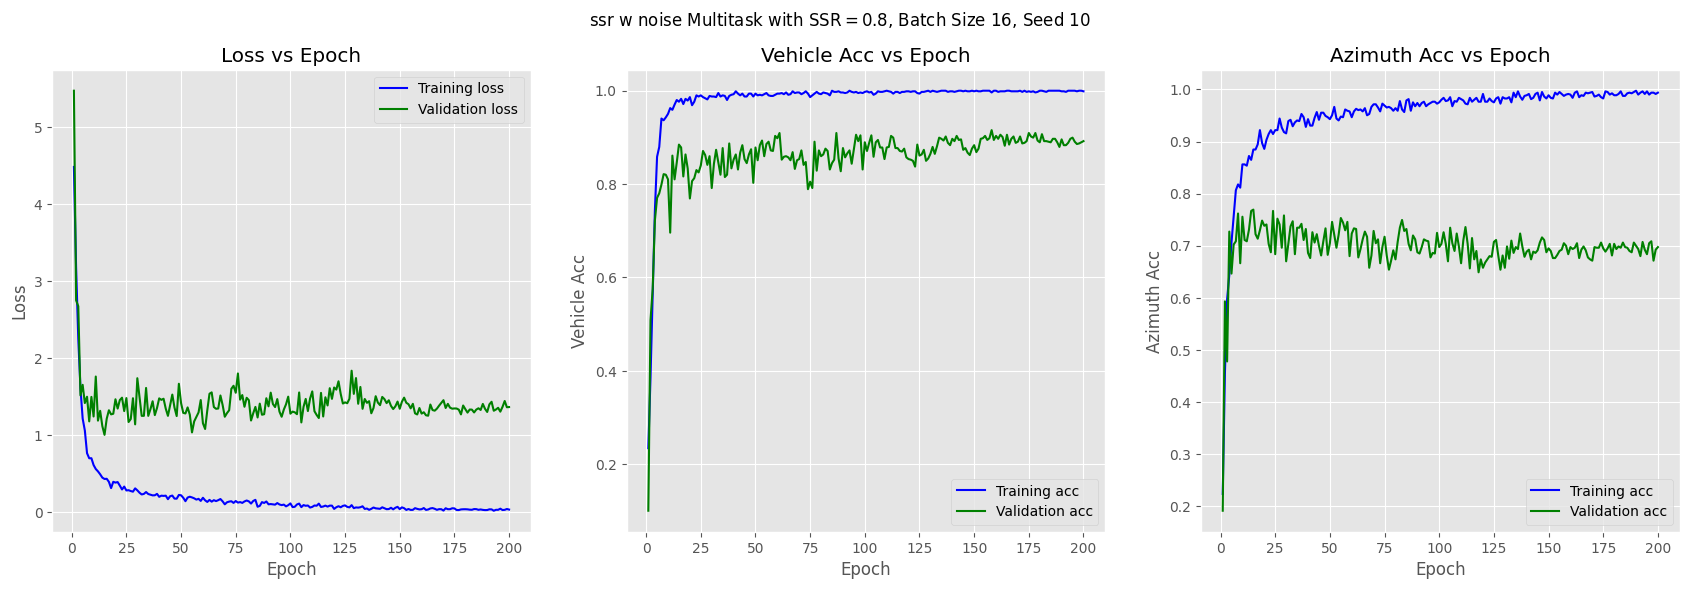

In [16]:
row, col = train_loss.shape

for i, seed in enumerate(seed_lst):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (21, 6))
    
        ax0 = fig.add_subplot(1, 3, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 3, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_vehicle_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_vehicle_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Vehicle Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Vehicle Acc")
        ax1.legend()
        ax1.grid(True)

        ax2 = fig.add_subplot(1, 3, 3)
        ax2.plot(np.arange(1, num_epochs+1), train_azimuth_acc[i, :], label = "Training acc", c = "blue")
        ax2.plot(np.arange(1, num_epochs+1), val_azimuth_acc[i, :], label = "Validation acc", c = "green")
        ax2.set_title("Azimuth Acc vs Epoch")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Azimuth Acc")
        ax2.legend()
        ax2.grid(True)
        
        fig.suptitle(rf"ssr w noise Multitask with SSR$=0.8$, Batch Size 16, Seed {seed}")
        plt.show()

In [17]:
test_dataloader = DataLoader(multitask_test_ds, batch_size=32, shuffle=False, 
                            num_workers=8, pin_memory=True, persistent_workers=True, 
                            prefetch_factor=4)

seed_lst = [10]
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i} with seed {seed}")
    
    model = MultiTaskResNet18(
        num_vehicle_classes=len(multitask_train_ds.vehicle_classes),
        num_azimuth_classes=len(multitask_train_ds.azimuth_classes)
    )
    # Load your trained weights
    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/multitask/SSR_w_noise_ncql/rn18_seed{seed}_b16_ssr_80_circ.pth"),
        map_location=device
    ))
    
    model = model.to(device)
    model.eval()

    n_test = dataset_sizes["test"]
    vehicle_labels_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    vehicle_preds_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    azimuth_labels_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    azimuth_preds_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    
    idx = 0
    with torch.no_grad():
        for inputs, vehicle_labels, azimuth_labels in test_dataloader:
            inputs = inputs.to(device)
            vehicle_labels = vehicle_labels.to(device)
            azimuth_labels = azimuth_labels.to(device)
    
            vehicle_logits, azimuth_logits = model(inputs)
            _, vehicle_preds = torch.max(vehicle_logits, 1)
            _, azimuth_preds = torch.max(azimuth_logits, 1)
    
            batch_size = vehicle_labels.size(0)
            vehicle_labels_tensor[idx : idx + batch_size] = vehicle_labels
            vehicle_preds_tensor[idx : idx + batch_size] = vehicle_preds
            azimuth_labels_tensor[idx : idx + batch_size] = azimuth_labels
            azimuth_preds_tensor[idx : idx + batch_size] = azimuth_preds
            idx += batch_size

    torch.cuda.synchronize()
    
    test_veh_acc = (vehicle_labels_tensor == vehicle_preds_tensor).float().mean()
    test_azimuth_acc = (azimuth_labels_tensor == azimuth_preds_tensor).float().mean()
    test_acc = ((vehicle_labels_tensor == vehicle_preds_tensor) & (azimuth_labels_tensor == azimuth_preds_tensor)).float().mean()
    print(f"Test Vehicle Accuracy: {test_veh_acc *100:.4f}\nTest Azimuth Accuracy: {test_azimuth_acc * 100:.4f}\nTest Joint Accuracy: {test_acc * 100:.4f}\n")
    test_acc_lst.append(test_acc.item())

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0 with seed 10
Test Vehicle Accuracy: 91.8367
Test Azimuth Accuracy: 74.5826
Test Joint Accuracy: 68.6456

Min: 68.6456
Max: 68.6456
Avg, Std: 68.6456, 0.0000


# $5 \times$ Normalised Circular Loss with SSR = 0.8 

In [17]:
# seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
seed_lst = [10]
vehicle_weight, azimuth_weight = 1.0, 1.0  # tune if one task dominates
circ_weight = 5.0

train_loss, val_loss = [], []
train_vehicle_acc, val_vehicle_acc = [], []
train_azimuth_acc, val_azimuth_acc = [], []

for i, seed in enumerate(seed_lst):
    start = time.perf_counter()
    
    print(f"Training Run {i}: seed {seed}")
    set_seed(seed)
    
    dataloaders = {
        "train": DataLoader(multitask_train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(multitask_valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(multitask_test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }

    model = MultiTaskResNet18(
        num_vehicle_classes=len(multitask_train_ds.vehicle_classes),
        num_azimuth_classes=len(multitask_train_ds.azimuth_classes)
    )

    criterion = nn.CrossEntropyLoss()
    circular_criterion = NormalisedCircularQuadraticLoss(num_azimuth_classes)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=2e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=200, eta_min=3e-7)

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    circular_criterion = circular_criterion.to(device)
    
    history = {
        "train_loss": [], "val_loss": [],
        "train_vehicle_acc": [], "val_vehicle_acc": [],
        "train_azimuth_acc": [], "val_azimuth_acc": []
    }

    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.trunk[0].weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_vehicle_corrects = 0
            running_azimuth_corrects = 0
            
            running_azimuth_ce = 0.0      # NEW
            running_azimuth_circ = 0.0    # NEW
            
            for inputs, vehicle_labels, azimuth_labels in dataloaders[phase]:
                inputs = inputs.to(device)
                vehicle_labels = vehicle_labels.to(device)
                azimuth_labels = azimuth_labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    vehicle_logits, azimuth_logits = model(inputs)
                    _, vehicle_preds = torch.max(vehicle_logits, 1)
                    _, azimuth_preds = torch.max(azimuth_logits, 1)

                    loss_vehicle = criterion(vehicle_logits, vehicle_labels)
                    
                    loss_azimuth_ce = criterion(azimuth_logits, azimuth_labels)
                    loss_azimuth_circ = circular_criterion(azimuth_logits, azimuth_labels)
                    loss_azimuth =  loss_azimuth_ce + circ_weight * loss_azimuth_circ
                    
                    loss = vehicle_weight * loss_vehicle + azimuth_weight * loss_azimuth
                    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_vehicle_corrects += (vehicle_preds == vehicle_labels).sum().item()
                running_azimuth_corrects += (azimuth_preds == azimuth_labels).sum().item()
                running_azimuth_ce += loss_azimuth_ce.item() * inputs.size(0)      # NEW
                running_azimuth_circ += loss_azimuth_circ.item() * inputs.size(0) # NEW

                
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_vehicle_acc = running_vehicle_corrects / dataset_sizes[phase]
            epoch_azimuth_acc = running_azimuth_corrects / dataset_sizes[phase]
            epoch_azimuth_ce = running_azimuth_ce / dataset_sizes[phase]      # NEW
            epoch_azimuth_circ = running_azimuth_circ / dataset_sizes[phase] # NEW

            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_vehicle_acc"].append(epoch_vehicle_acc)
            history[f"{phase}_azimuth_acc"].append(epoch_azimuth_acc)

            print(f"{phase} Loss: {epoch_loss:.10f} Vehicle Acc: {epoch_vehicle_acc:.10f} Azimuth Acc: {epoch_azimuth_acc:.10f}")
            if phase == "train":
                print(f"CE: {epoch_azimuth_ce:.10f}  weighted Circ: {circ_weight * epoch_azimuth_circ:.10f}")
            
            
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")

    print("Training complete!")

    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_vehicle_acc.append(history["train_vehicle_acc"])
    val_vehicle_acc.append(history["val_vehicle_acc"])
    train_azimuth_acc.append(history["train_azimuth_acc"])
    val_azimuth_acc.append(history["val_azimuth_acc"])

    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/multitask/SSR_w_noise_ncql/rn18_seed{seed}_b16_ssr_80_circ5.pth"))
    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")

train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_vehicle_acc = np.array(train_vehicle_acc)
val_vehicle_acc = np.array(val_vehicle_acc)
train_azimuth_acc = np.array(train_azimuth_acc)
val_azimuth_acc = np.array(val_azimuth_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000224
train Loss: 5.8019208364 Vehicle Acc: 0.2307692308 Azimuth Acc: 0.2419354839
CE: 1.9319955059  weighted Circ: 1.7206878553
val Loss: 6.1323403886 Vehicle Acc: 0.0955334988 Azimuth Acc: 0.3709677419
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 3.5973331946 Vehicle Acc: 0.3461538462 Azimuth Acc: 0.5297766749
CE: 1.1078675372  weighted Circ: 0.6794595758
val Loss: 3.0930210630 Vehicle Acc: 0.3933002481 Azimuth Acc: 0.6277915633
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 2.6686586730 Vehicle Acc: 0.4851116625 Azimuth Acc: 0.6488833747
CE: 0.8517028496  weighted Circ: 0.4068347823
val Loss: 2.8670876399 Vehicle Acc: 0.5694789082 Azimuth Acc: 0.5955334988
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 2.0382093354 Vehicle Acc: 0.6253101737 Azimuth Acc: 0.7196029777
CE: 0.6971950217  weighted Circ: 0.3073440138
val Loss: 1.9488377170 Vehicle Acc: 0.7233250620 Azimuth Acc: 0.7071960298
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 1.549

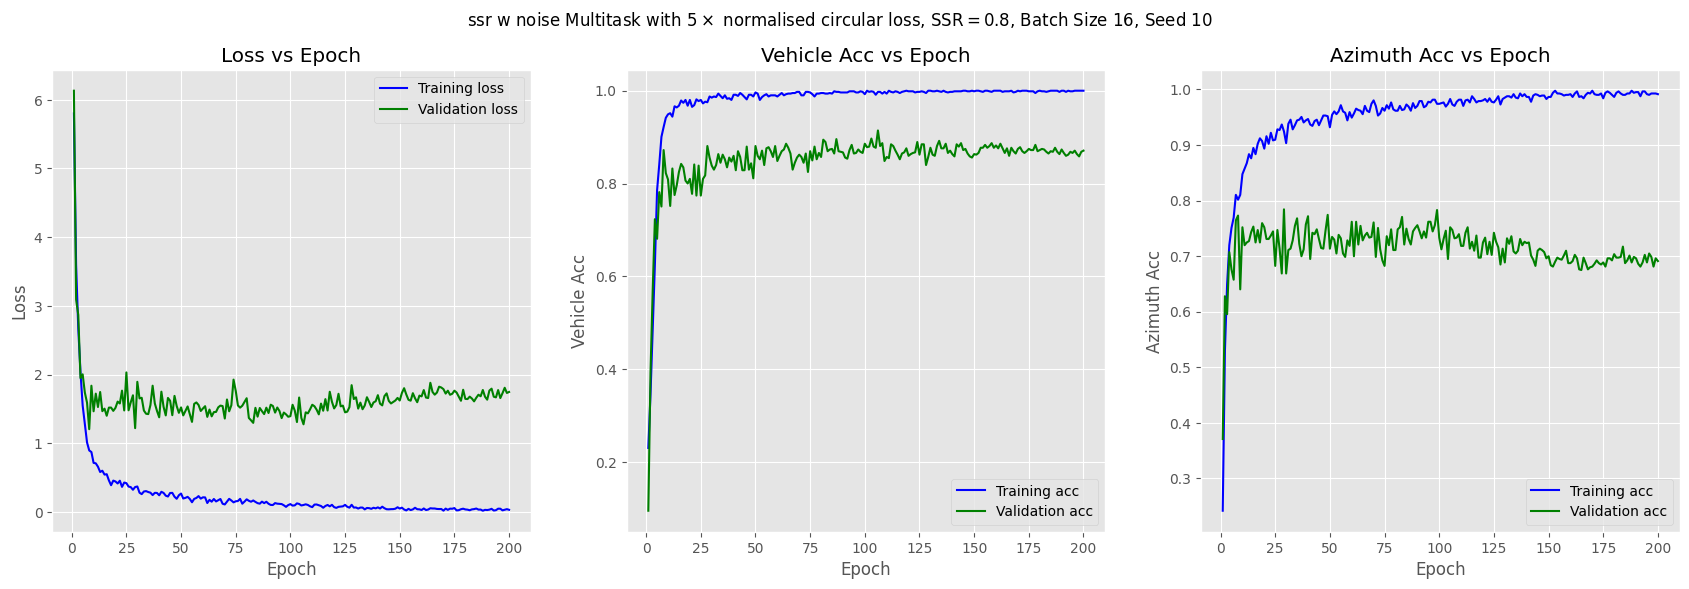

In [18]:
row, col = train_loss.shape

for i, seed in enumerate(seed_lst):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (21, 6))
    
        ax0 = fig.add_subplot(1, 3, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 3, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_vehicle_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_vehicle_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Vehicle Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Vehicle Acc")
        ax1.legend()
        ax1.grid(True)

        ax2 = fig.add_subplot(1, 3, 3)
        ax2.plot(np.arange(1, num_epochs+1), train_azimuth_acc[i, :], label = "Training acc", c = "blue")
        ax2.plot(np.arange(1, num_epochs+1), val_azimuth_acc[i, :], label = "Validation acc", c = "green")
        ax2.set_title("Azimuth Acc vs Epoch")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Azimuth Acc")
        ax2.legend()
        ax2.grid(True)
        
        fig.suptitle(rf"ssr w noise Multitask with $5 \times $ normalised circular loss, SSR$=0.8$, Batch Size 16, Seed {seed}")
        plt.show()

In [18]:
test_dataloader = DataLoader(multitask_test_ds, batch_size=32, shuffle=False, 
                            num_workers=8, pin_memory=True, persistent_workers=True, 
                            prefetch_factor=4)

seed_lst = [10]
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i} with seed {seed}")
    
    model = MultiTaskResNet18(
        num_vehicle_classes=len(multitask_train_ds.vehicle_classes),
        num_azimuth_classes=len(multitask_train_ds.azimuth_classes)
    )
    # Load your trained weights
    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/multitask/SSR_w_noise_ncql/rn18_seed{seed}_b16_ssr_80_circ5.pth"),
        map_location=device
    ))
    
    model = model.to(device)
    model.eval()

    n_test = dataset_sizes["test"]
    vehicle_labels_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    vehicle_preds_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    azimuth_labels_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    azimuth_preds_tensor = torch.zeros(n_test, dtype = torch.long, device = device)
    
    idx = 0
    with torch.no_grad():
        for inputs, vehicle_labels, azimuth_labels in test_dataloader:
            inputs = inputs.to(device)
            vehicle_labels = vehicle_labels.to(device)
            azimuth_labels = azimuth_labels.to(device)
    
            vehicle_logits, azimuth_logits = model(inputs)
            _, vehicle_preds = torch.max(vehicle_logits, 1)
            _, azimuth_preds = torch.max(azimuth_logits, 1)
    
            batch_size = vehicle_labels.size(0)
            vehicle_labels_tensor[idx : idx + batch_size] = vehicle_labels
            vehicle_preds_tensor[idx : idx + batch_size] = vehicle_preds
            azimuth_labels_tensor[idx : idx + batch_size] = azimuth_labels
            azimuth_preds_tensor[idx : idx + batch_size] = azimuth_preds
            idx += batch_size

    torch.cuda.synchronize()
    
    test_veh_acc = (vehicle_labels_tensor == vehicle_preds_tensor).float().mean()
    test_azimuth_acc = (azimuth_labels_tensor == azimuth_preds_tensor).float().mean()
    test_acc = ((vehicle_labels_tensor == vehicle_preds_tensor) & (azimuth_labels_tensor == azimuth_preds_tensor)).float().mean()
    print(f"Test Vehicle Accuracy: {test_veh_acc *100:.4f}\nTest Azimuth Accuracy: {test_azimuth_acc * 100:.4f}\nTest Joint Accuracy: {test_acc * 100:.4f}\n")
    test_acc_lst.append(test_acc.item())

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0 with seed 10
Test Vehicle Accuracy: 89.4249
Test Azimuth Accuracy: 73.2839
Test Joint Accuracy: 66.0482

Min: 66.0482
Max: 66.0482
Avg, Std: 66.0482, 0.0000
